# Scatterplot of ensemble members showing which constraints cut which ensemble members for all PPEs
Revised version

In [1]:
import pickle

import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import matplotlib.patches as mpatches
import tol_colors as tc
import multi_ppe_constraint_rev as mpc

from matplotlib.gridspec import GridSpec


In [2]:
main_path = "/glade/u/home/jnug/work/multi_PPE_data/"
file_path = main_path + "annual_means/"
save_dir = "/glade/work/jnug/codes/e3sm-ppe-aci/analysis/notebooks/multi_PPE_adj/revisions/figures/"
pickle_path = main_path + "pickle_jar/"


### Get data

#### PPE & CMIP6

In [3]:
ds_e3sm = xr.open_dataset(file_path + "E3SMv3_data_annual_means.nc")
ds_ga71 = xr.open_dataset(file_path + "GA7.1_data_annual_means.nc")
ds_cam6 = xr.open_dataset(file_path + "CAM6_data_annual_means.nc") 
ds_eham = xr.open_dataset(file_path + "ECHAM6-HAM_data_annual_means.nc") 

# add da/dlwp to PPE members
with open(pickle_path + "PPE_dadlwp_dict.pickle", "rb") as handle:
    ppe_dadlwp_dict = pickle.load(handle)
ds_e3sm = ds_e3sm.assign({"dadlwp": ppe_dadlwp_dict["E3SMv3"].rename({"LWP_pd_masked", "dadlwp"})})
ds_ga71 = ds_ga71.assign({"dadlwp": ppe_dadlwp_dict["GA7.1"].rename({"LWP_pd_masked", "dadlwp"})})
ds_cam6 = ds_cam6.assign({"dadlwp": ppe_dadlwp_dict["CAM6"].rename({"LWP_pd_masked", "dadlwp"})})
ds_eham = ds_eham.assign({"dadlwp": ppe_dadlwp_dict["ECHAM6-HAM"].rename({"LWP_pd_masked", "dadlwp"})})

# make a PPE dataset dictionary
ds_dict = {"E3SMv3": ds_e3sm, "GA7.1": ds_ga71, "CAM6": ds_cam6, "ECHAM6-HAM": ds_eham}


In [4]:
# constraints
ppe_constr_dict = {}
for ppe in list(ds_dict.keys()):
    ppe_constr_dict[ppe] = mpc.read_obs_constraints(ppe, out_path=pickle_path, extra="_error_tol_0.05")


#### Observational ranges
Hardcode, values from other NBs

In [8]:
dnd_obs_range = mpc.DELTA_ND
dadlwp_obs_range = mpc.DADLWP

# account for 5% tolerance
dadlwp_obs_range_tol = np.multiply(dadlwp_obs_range, [0.95, 1.05])
dnd_obs_range_tol = np.multiply(dnd_obs_range, [0.95, 1.05])


### Plot!

In [7]:
figsize = (12, 13)

fsize = 14
labsize = 11
tsize = 16

obs_alpha = 0.5
dnd_col = "#BBCCEE"
dadlwp_col = "#CCDDAA"
box_lw = 1.5

bad_col = "k"
good_col= "#0077BB"
ppe_alpha = 0.5
ppe_s = 20

yscale = "log"
xscale = "log"
ylim = (1, 100)
xlim = (0.1, 400)


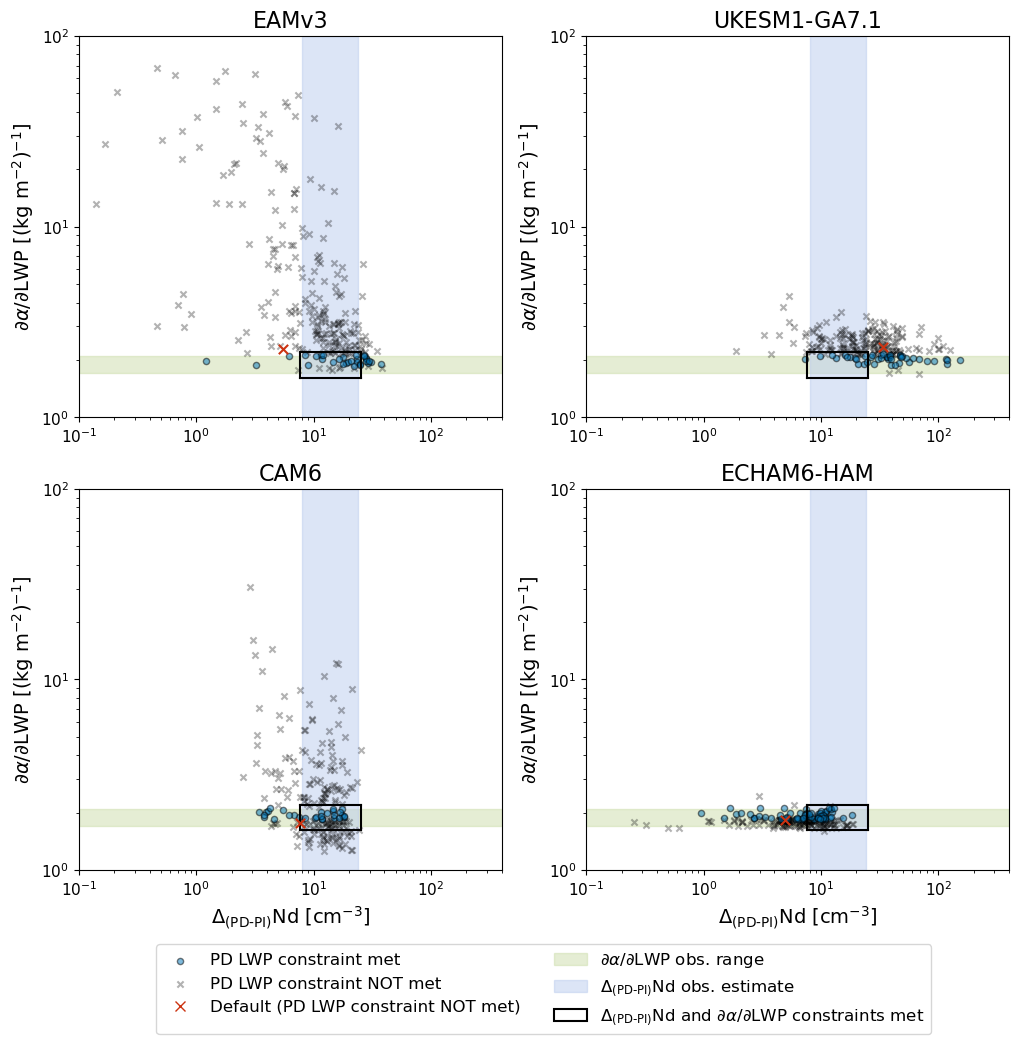

In [9]:
fig = plt.figure(figsize=figsize)
gs = GridSpec(3, 2, height_ratios=[1, 1, 0.25])#, width_ratios=[1, 0.2])
plt.subplots_adjust(hspace=0.25)

# legend
ax_leg = plt.subplot(gs[2, :])
ax_leg.axis("off")

axes = [plt.subplot(gs[0, 0]), plt.subplot(gs[0, 1]), plt.subplot(gs[1, 0]), plt.subplot(gs[1, 1])]

# --- plot PPEs ---
for i, ppe in enumerate(list(ds_dict.keys())):
    ds = ds_dict[ppe]
    ax = axes[i]

    # set up axes
    if ppe == "E3SMv3":
        lab = "EAMv3"
    elif ppe == "GA7.1":
        lab = "UKESM1-GA7.1"
    else:
        lab = ppe
    ax.set_title(lab, fontsize=tsize)
    ax.set_yscale(yscale)
    ax.set_xscale(xscale)
    ax.set_ylim(ylim)
    ax.set_xlim(xlim)
    ax.axhspan(dadlwp_obs_range[0], dadlwp_obs_range[1], color=dadlwp_col, alpha=obs_alpha, 
               label=r"$\partial \alpha$/$\partial \text{LWP}$ obs. range")
    ax.axvspan(dnd_obs_range[0], dnd_obs_range[1], color=dnd_col, alpha=obs_alpha, 
               label=r"$\Delta_\text{(PD-PI)}$Nd obs. estimate")
    ax.set_ylabel(r"$\partial\alpha$/$\partial\text{LWP}$ [(kg m$^{-2}$)$^{-1}$]", fontsize=fsize)
    if i > 1: # only on bottom row
        ax.set_xlabel(r"$\Delta_\text{(PD-PI)}$Nd [cm$^{-3}$]", fontsize=fsize)
    ax.tick_params(axis="both", labelsize=labsize)

    # plot ensemble members (skip the default)
    good = ppe_constr_dict[ppe]["LWP_pd"]["match"]
    bad = ppe_constr_dict[ppe]["LWP_pd"]["cut"]
    if ppe != "CAM6": 
        bad_no_df = [x for x in bad if x != 0]
        good_no_df = [x for x in good if x != 0]
    else:
        bad_no_df = [x for x in bad if x != "000"]
        good_no_df = [x for x in good if x != "000"]
    ax.scatter(ds["delta_Nd_ocn"].sel(member=bad_no_df), ds["dadlwp"].sel(member=bad_no_df),
               color=bad_col, marker="x", s=ppe_s, alpha=0.3,
              label=r"PD LWP constraint NOT met")
    ax.scatter(ds["delta_Nd_ocn"].sel(member=good_no_df), ds["dadlwp"].sel(member=good_no_df),
               color=good_col, marker="o", s=ppe_s, alpha=ppe_alpha, edgecolor="k",
              label="PD LWP constraint met")

    # obs constraint box
    y1, y2 = dadlwp_obs_range_tol
    x1, x2 = dnd_obs_range_tol
    ax.plot([x1, x2], [y1, y1], color="k", linewidth=box_lw)
    ax.plot([x1, x2], [y2, y2], color="k", linewidth=box_lw)
    ax.plot([x1, x1], [y1, y2], color="k", linewidth=box_lw)
    ax.plot([x2, x2], [y1, y2], color="k", linewidth=box_lw)

    # plot the default last
    if 0 in good:
        m = "o"
        edgecol = "k"
        color = good_col
        s = ppe_s*2
    else:
        m = "x"
        edgecol = None
        color = "#CC3311"
        s = ppe_s*2 + 5
    if ppe == "CAM6":
        idf = "000"
    else:
        idf = 0
    ax.scatter(ds["delta_Nd_ocn"].sel(member=idf), ds["dadlwp"].sel(member=idf), 
               color=color, marker=m, edgecolor=edgecol, s=s, alpha=1, zorder=999)


# --- legend ---
handles, labels = ax.get_legend_handles_labels()

# reorder
new_order = [3, 2, 0, 1]
handles = [handles[i] for i in new_order]
labels = [labels[i] for i in new_order]

# proxy artists for the default
# handles.insert(2, mlines.Line2D([], [], marker="o", color=good_col, markeredgecolor="k", markersize=7, linestyle=""))
# labels.insert(2, r"Default (PD LWP constraint met)")
handles.insert(2, mlines.Line2D([], [], marker="x", color="#CC3311", linestyle="", markersize=7))
labels.insert(2, r"Default (PD LWP constraint NOT met)")

# proxy artist for the rectangle
handles.append(mpatches.Patch(color="k", fill=False, linewidth=box_lw))
labels.append(r"$\Delta_\text{(PD-PI)}$Nd and $\partial\alpha$/$\partial\text{LWP}$"+" constraints met")

# plot
ax_leg.legend(handles=handles, labels=labels, loc="center", fontsize=fsize-2, ncol=2)


# --- save ---
plt.savefig(save_dir + "FigS1_ens_constraint_visual_Ndpipd.png", dpi=300, bbox_inches="tight")

plt.show()

